In [1]:
from pathlib import Path
from datetime import datetime
import json, time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device, '| PyTorch:', torch.__version__)
assert device == 'cuda', 'GPU not visible — stop and check'

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
models_dir = root / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.read_csv(data_dir / 'metrics.csv', parse_dates=['timestamp'])
print('Metrics rows:', len(metrics_df))

Device: cuda | PyTorch: 2.8.0+gitb2fb688
Metrics rows: 964


In [2]:
METRICS = ['cpu_utilization', 'rps', 'latency_p95_ms', 'error_rate']
WINDOW = 12  # 12-minute sliding windows

windows, window_meta = [], []

for service, sdf in metrics_df.groupby('service'):
    sdf = sdf.sort_values('timestamp').reset_index(drop=True)
    vals = sdf[METRICS].to_numpy(dtype=np.float32)

    # Per-service z-score normalization (robust to service baseline differences)
    mu, sigma = vals.mean(axis=0), vals.std(axis=0) + 1e-8
    norm = (vals - mu) / sigma

    for i in range(len(norm) - WINDOW + 1):
        windows.append(norm[i:i+WINDOW].flatten())   # 12 × 4 = 48 features
        window_meta.append({
            'service': service,
            'start_time': sdf.timestamp.iloc[i],
            'end_time': sdf.timestamp.iloc[i+WINDOW-1],
        })

X = np.stack(windows)
meta_df = pd.DataFrame(window_meta)
print(f'Windows: {X.shape[0]} | features per window: {X.shape[1]} (={WINDOW}min × {len(METRICS)} metrics)')

Windows: 920 | features per window: 48 (=12min × 4 metrics)


In [3]:
class MetricAutoencoder(nn.Module):
    def __init__(self, input_dim=48, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = MetricAutoencoder(input_dim=X.shape[1]).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Autoencoder: 48 → 32 → 8 → 32 → 48 | {n_params:,} parameters | on {torch.cuda.get_device_name(0) or "MI300X"}')

Autoencoder: 48 → 32 → 8 → 32 → 48 | 3,704 parameters | on MI300X


Epoch  50/300 | loss: 0.13736
Epoch 100/300 | loss: 0.13208
Epoch 150/300 | loss: 0.12750
Epoch 200/300 | loss: 0.12302
Epoch 250/300 | loss: 0.11937
Epoch 300/300 | loss: 0.11672

🏁 GPU training: 300 epochs on 920 windows in 1.00s (276,187 window-epochs/sec on MI300X)


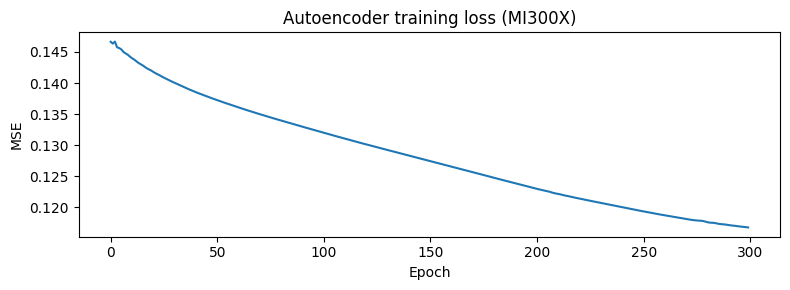

In [5]:
X_t = torch.from_numpy(X).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 300
losses = []

torch.cuda.synchronize()
t0 = time.perf_counter()

model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    recon = model(X_t)
    loss = criterion(recon, X_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | loss: {loss.item():.5f}')

torch.cuda.synchronize()
train_time = time.perf_counter() - t0

print(f'\n🏁 GPU training: {EPOCHS} epochs on {X.shape[0]} windows in {train_time:.2f}s '
      f'({EPOCHS * X.shape[0] / train_time:,.0f} window-epochs/sec on MI300X)')

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title('Autoencoder training loss (MI300X)')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.tight_layout(); plt.show()

In [8]:
model.eval()
torch.cuda.synchronize(); t0 = time.perf_counter()
with torch.no_grad():
    recon = model(X_t)
    errors = ((recon - X_t) ** 2).mean(dim=1).cpu().numpy()
torch.cuda.synchronize()
infer_time = time.perf_counter() - t0

meta_df['recon_error'] = errors
threshold = np.percentile(errors, 97)   # top 3% = anomalous windows
meta_df['ae_anomaly'] = meta_df['recon_error'] > threshold

print(f'Inference: {X.shape[0]} windows scored in {infer_time*1000:.1f}ms ({X.shape[0]/infer_time:,.0f} windows/sec)')
print(f'Anomaly threshold (p97): {threshold:.4f}')
print(f'\nAnomalous windows by service:')
print(meta_df[meta_df.ae_anomaly].groupby('service').size())

Inference: 920 windows scored in 1.9ms (481,550 windows/sec)
Anomaly threshold (p97): 0.3024

Anomalous windows by service:
service
auth-service        14
checkout-api         2
payments-service    12
dtype: int64


Detection check — does the autoencoder catch each injected incident?

✅ DETECTED | payments-service   | 12 anomalous windows | peak error 0.489 (threshold 0.302)
✅ DETECTED | checkout-api       |  2 anomalous windows | peak error 0.340 (threshold 0.302)
✅ DETECTED | auth-service       | 14 anomalous windows | peak error 0.386 (threshold 0.302)

Recall on injected incidents: 3/3


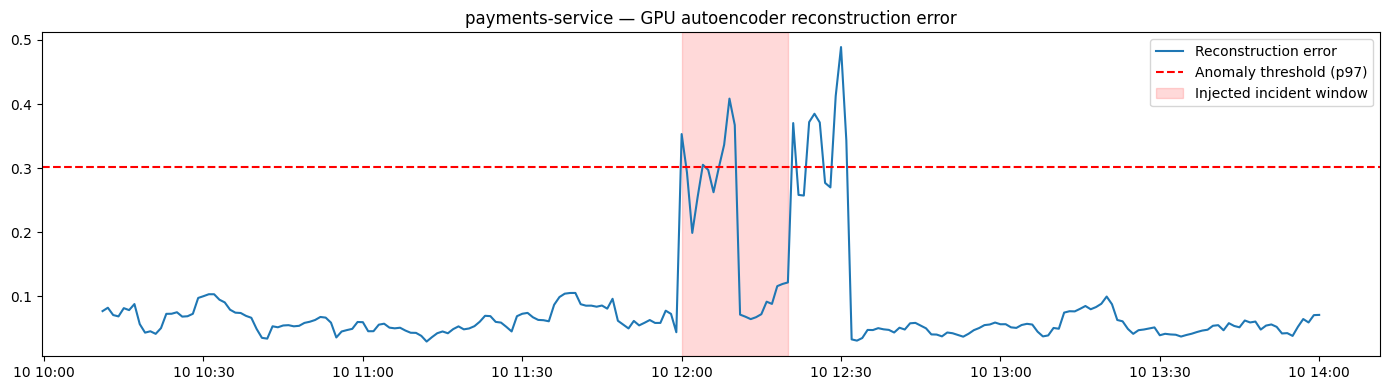

In [10]:
# Ground truth: the three injected incident windows from Phase 2
INJECTED = {
    'payments-service': ('2026-06-10 12:00', '2026-06-10 12:20'),
    'checkout-api':     ('2026-06-10 11:00', '2026-06-10 11:20'),
    'auth-service':     ('2026-06-10 13:00', '2026-06-10 13:15'),
}

print('Detection check — does the autoencoder catch each injected incident?\n')
caught = 0
for svc, (s, e) in INJECTED.items():
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    overlap = meta_df[(meta_df.service == svc) & meta_df.ae_anomaly &
                      (meta_df.end_time >= s) & (meta_df.start_time <= e)]
    status = '✅ DETECTED' if len(overlap) > 0 else '❌ MISSED'
    caught += int(len(overlap) > 0)
    peak = meta_df[(meta_df.service == svc) & (meta_df.end_time >= s) & (meta_df.start_time <= e)].recon_error.max()
    print(f'{status} | {svc:18s} | {len(overlap):2d} anomalous windows | peak error {peak:.3f} (threshold {threshold:.3f})')

print(f'\nRecall on injected incidents: {caught}/3')

# Visual: reconstruction error timeline for payments-service with incident shaded
fig, ax = plt.subplots(figsize=(14, 4))
svc_meta = meta_df[meta_df.service == 'payments-service']
ax.plot(svc_meta.end_time, svc_meta.recon_error, lw=1.5, label='Reconstruction error')
ax.axhline(threshold, color='red', ls='--', label='Anomaly threshold (p97)')
ax.axvspan(pd.Timestamp('2026-06-10 12:00'), pd.Timestamp('2026-06-10 12:20'),
           color='red', alpha=0.15, label='Injected incident window')
ax.set_title('payments-service — GPU autoencoder reconstruction error')
ax.legend(); plt.tight_layout(); plt.show()

In [11]:
torch.save(model.state_dict(), models_dir / 'metric_autoencoder.pt')
meta_df.to_parquet(models_dir / 'ae_anomaly_scores.parquet', index=False)

benchmark = {
    'model': 'MetricAutoencoder 48-32-8-32-48',
    'parameters': int(n_params),
    'device': 'AMD Instinct MI300X (ROCm)',
    'training_windows': int(X.shape[0]),
    'epochs': EPOCHS,
    'train_time_sec': round(train_time, 3),
    'window_epochs_per_sec': round(EPOCHS * X.shape[0] / train_time),
    'inference_windows_per_sec': round(X.shape[0] / infer_time),
    'recall_on_injected_incidents': f'{caught}/3',
    'anomaly_threshold_percentile': 97,
}
with open(models_dir / 'ae_benchmark.json', 'w') as f:
    json.dump(benchmark, f, indent=2)

display(Markdown('### GPU Anomaly Detection — Benchmark (for slides)'))
display(pd.DataFrame([benchmark]).T.rename(columns={0: 'value'}))
print('Saved: metric_autoencoder.pt, ae_anomaly_scores.parquet, ae_benchmark.json')

### GPU Anomaly Detection — Benchmark (for slides)

,value
model,MetricAutoencoder 48-32-8-32-48
parameters,3704
device,AMD Instinct MI300X (ROCm)
training_windows,920
epochs,300
train_time_sec,0.999
window_epochs_per_sec,276187
inference_windows_per_sec,481550
recall_on_injected_incidents,3/3
anomaly_threshold_percentile,97


Saved: metric_autoencoder.pt, ae_anomaly_scores.parquet, ae_benchmark.json
